In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):
    """Message have the type 'list[dict[str,str]]. that add massage function
    in the annotated defines how this state key should be updated,
    in this case it appends the new message to the existing list of the message """
    messages : Annotated[list,add_messages]
    
graph_builder = StateGraph(State)
graph_builder

In [4]:
## LLM
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm = ChatGroq(
    model= 'qwen/qwen3.8-27b',
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.5,
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x766db1f7a510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x766db1f7b230>, model_name='qwen/qwen3.8-27b', temperature=0.5, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from langchain_openai import ChatOpenAI
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set. Add it to your .env file or export it in the environment.")

openai_llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=api_key,
)
openai_llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3', 'langchain-openai': '1.6.7'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x766db0dfbcb0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x766db0bc4830>, root_client=<openai.OpenAI object at 0x766db0dfb4d0>, root_async

In [6]:
llm = init_chat_model('groq:qwen/qwen3.8-27b')
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x766db0defd90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x766db0bcc7d0>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
# Node functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

def chatbot_open_ai(state:State):
    return {"messages": [openai_llm.invoke(state['messages'])]}


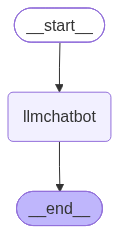

In [8]:
graph_builder = StateGraph(State)

# Adding Node to the graph
graph_builder.add_node("llmchatbot",chatbot)



# Adding the edge to the graph
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge('llmchatbot',END)

# compliling the graph
graph = graph_builder.compile()
graph

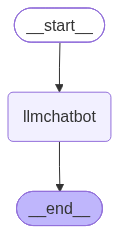

In [9]:
graph_builder_openai = StateGraph(State)

# Adding Node to the graph
graph_builder_openai.add_node("llmchatbot",chatbot_open_ai)



# Adding the edge to the graph
graph_builder_openai.add_edge(START,"llmchatbot")
graph_builder_openai.add_edge('llmchatbot',END)

# compliling the graph
graph_openai = graph_builder_openai.compile()
graph_openai

In [10]:
# ## check the response form the chatbot
# response = graph.invoke({'messages':"hello"})
# response

In [11]:
result = graph_openai.invoke({'messages':"hello"})
result

{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='e718bb45-ff99-44b1-ac40-9556cba86f3e'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0f833288d6', 'id': 'chatcmpl-EVzLiLv1E5E6XftqMAizBCnosXr4w', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a1115d-7b82-71a1-8d9c-9984f4892b6e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'tot

In [12]:
# user_message =input("Ask the question")
# for event in graph.stream({'messages':user_message}):
#     for message in event.values():
#         print(message['messages'][-1].content)

### Tool adding for the chatbot

In [13]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_result =2)
result = tool.invoke("what is langchain")
result

{'query': 'what is langchain',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.oracle.com/database/what-is-langchain',
   'title': 'What is LangChain? | Oracle',
   'content': 'LangChain is an open source framework for building applications with large language models by connecting models to data, tools, and workflows. It provides building blocks—prompts, retrievers for RAG, tools, and agent patterns, including LangGraph—so LLMs can fetch context, call APIs, and produce structured outputs with tracing and evaluation via LangSmith. In short, LangChain helps development teams move from prototypes to reliable production applications that use AI and AI agents. [...] LangChain is an open source framework for building LLM applications that combine prompt templates, memory, data connectors, tools, retrieval, and AI agents. Its standardized abstractions, including chains, retrievers, and agents, give developers reusable building blocks for orchest

In [14]:
# Custome function
def multiply(a:float,b:float) ->float:
    """ 
    multiply a and b
    Args
    a(flaot): first float value
    b(flaot): second float value
    
    return:
    float : output float
     
    """
    return a*b

In [15]:
tools = [ tool, multiply]

In [16]:
llm_with_tool = openai_llm.bind_tools(tools=tools)
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3', 'langchain-openai': '1.6.7'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x766db0dfbcb0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x766db0bc4830>, root_client=<openai.OpenAI object at 0x7

In [17]:
## Stategraph
from langgraph.graph import StateGraph,END,START
from langgraph.prebuilt import ToolNode, tools_condition


In [18]:
# Node dafination
def tool_calling_llm(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}

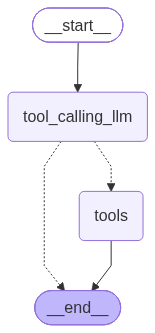

In [19]:
#graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# add the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools',END)

builder_graph = builder.compile()

builder_graph

In [20]:
open_response = builder_graph.invoke({'messages': "what is cuurent ai news "})
open_response

{'messages': [HumanMessage(content='what is cuurent ai news ', additional_kwargs={}, response_metadata={}, id='560e77bb-e0d4-41b0-83f2-8b9439f7c593'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1245, 'total_tokens': 1272, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVzLpcqrJU7DL0g7X7ihrVNurInL8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a1115d-9505-7d71-a9f5-7d378b5e6073-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI news', 'topic': 'news', 'time_ra

In [21]:
open_response['messages']

[HumanMessage(content='what is cuurent ai news ', additional_kwargs={}, response_metadata={}, id='560e77bb-e0d4-41b0-83f2-8b9439f7c593'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1245, 'total_tokens': 1272, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVzLpcqrJU7DL0g7X7ihrVNurInL8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a1115d-9505-7d71-a9f5-7d378b5e6073-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI news', 'topic': 'news', 'time_range': 'week'},

In [22]:
open_response['messages'][-1].content

'{"query": "current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Noimos.ai launched a customer engagement agent to automate behavior-based marketing actions. The agent tracks customer activity patterns, triggers contextual messages across digital channels, and manages retention workflows.\\n\\nOpenArt introduced OpenArt Arena, a benchmark platform for creative image models. The system evaluates generative model performance through side-by-side user preference testing and ranks visual output quality across specific artistic styles. [...] Gong released Mission Callisto, an AI sales enrichment layer for revenue teams. The update captures customer interaction signals across sales calls, extracts deal insights, enriches buyer profiles, and syncs actionable account metrics into sales workflows.\\n\\nGuidelin

In [23]:
for m in open_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is cuurent ai news 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_Sl8IhJ1DeFGeVhHXstRgwvWl)
 Call ID: call_Sl8IhJ1DeFGeVhHXstRgwvWl
  Args:
    query: current AI news
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Noimos.ai launched a customer engagement agent to automate behavior-based marketing actions. The agent tracks customer activity patterns, triggers contextual messages across digital channels, and manages retention workflows.\n\nOpenArt introduced OpenArt Arena, a benchmark platform for 

In [24]:
# open_response = builder_graph.invoke({'messages': "what is cuurent ai news "})
# open_response
# for m in open_response['messages']:
#     m.pretty_print()

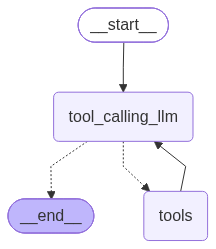

In [25]:
# Graph
builder = StateGraph(State)

# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges
builder.add_edge(START, "tool_calling_llm")

# If LLM makes a tool call -> tools
# If LLM does not make a tool call -> END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# After executing the tool, go back to the LLM
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
builder_graph = builder.compile()

builder_graph


In [26]:
open_response = builder_graph.invoke({'messages': "what is cuurent ai news and what is the 5 multply with 93"})
open_response
for m in open_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is cuurent ai news and what is the 5 multply with 93
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_5A00g2LNXF871XcKmuNK60tj)
 Call ID: call_5A00g2LNXF871XcKmuNK60tj
  Args:
    query: current AI news
    topic: news
    time_range: week
  multiply (call_oNnMJwyvzSAzPxvzPI4a9mtj)
 Call ID: call_oNnMJwyvzSAzPxvzPI4a9mtj
  Args:
    a: 5
    b: 93
================================= Tool Message =================================
Name: tavily_search

{"query": "current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Noimos.ai launched a customer engagement agent to automate behavior-based marketing actions. The agent tracks customer activity patterns, trigge

In [27]:
from rich.console import Console
from rich.markdown import Markdown

console = Console()

markdown_text = m.content

# Render and print to the terminal
rendered_md = Markdown(markdown_text)
console.print(rendered_md)


ModuleNotFoundError: No module named 'rich'

### Adding the memory in the Agentic Graph

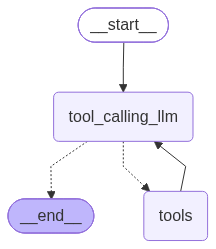

In [34]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()


# Graph
builder = StateGraph(State)

# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges
builder.add_edge(START, "tool_calling_llm")

# If LLM makes a tool call -> tools
# If LLM does not make a tool call -> END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# After executing the tool, go back to the LLM
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
builder_graph = builder.compile(checkpointer=memory)

builder_graph


In [35]:
# Config the key
config = {"configurable":{"thread_id":"1"}}

In [36]:
response = builder_graph.invoke({'messages':"hell my name is sheshpal"},config=config)
response

{'messages': [HumanMessage(content='hell my name is sheshpal', additional_kwargs={}, response_metadata={}, id='a81a1a72-b71b-44ce-aac2-3420dbb7b565'),
  AIMessage(content='Hello Sheshpal! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1245, 'total_tokens': 1258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVzd75GVPMuHkhI9cATMVIFW3z74a', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a1116d-f162-7661-b0a0-e237e91d2c8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [37]:
response['messages'][-1]

AIMessage(content='Hello Sheshpal! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1245, 'total_tokens': 1258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVzd75GVPMuHkhI9cATMVIFW3z74a', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a1116d-f162-7661-b0a0-e237e91d2c8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1245, 'output_tokens': 13, 'total_tokens': 1258, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 

In [40]:
response = builder_graph.invoke({'messages':"what is my name"},config=config)
response

{'messages': [HumanMessage(content='hell my name is sheshpal', additional_kwargs={}, response_metadata={}, id='a81a1a72-b71b-44ce-aac2-3420dbb7b565'),
  AIMessage(content='Hello Sheshpal! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1245, 'total_tokens': 1258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVzd75GVPMuHkhI9cATMVIFW3z74a', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a1116d-f162-7661-b0a0-e237e91d2c8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [39]:
user_message =input("Ask the question")
if user_message!='exit':
    
    for event in builder_graph.stream({'messages':user_message},config=config):
        for message in event.values():
            print(message['messages'][-1].content)
else:
    print("session finished") 



Your name is Sheshpal. How can I help you today?


### Streaming

In [41]:
def superbot(state:State):
    return {'messages':[llm.invoke(state['messages'])]}

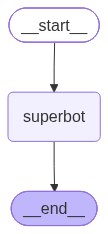

In [42]:
graph =StateGraph(State)

# node
graph.add_node("superbot",superbot)

# Add edge
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

# comple the graph
super_graph = graph.compile(checkpointer=memory)
super_graph

In [47]:
# create thread
config1 = {"configurable": {"thread_id": "2"}}

respose = super_graph.invoke(
    {"messages": "my name is sheshpal, i like reading"},
    config=config1
)
respose

{'messages': [HumanMessage(content='my name is sheshpal, i like reading', additional_kwargs={}, response_metadata={}, id='4d3b5d14-1942-4ab2-8085-36a54a6ba68a'),
  AIMessage(content='Hello, Sheshpal! It’s great to meet you.\n\nReading is a wonderful hobby—it’s a gateway to new perspectives, knowledge, and relaxation. Do you have a favorite genre or a particular author you’re currently enjoying? Or perhaps you’d like some recommendations based on what you’ve read recently? I’d love to hear more about your reading interests! 📚', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 22, 'total_tokens': 99, 'completion_time': 0.149564502, 'completion_tokens_details': None, 'prompt_time': 0.001213025, 'prompt_tokens_details': None, 'queue_time': 0.050182674, 'total_time': 0.150777527}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 

### Streaming

 **Methods: `.stream()` and `astream()`**

 - These methods are sync and async methods for streaming back results.

 **Additional parameters in streaming modes for graph state**

 - **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.

## Extracted text

 ### Streaming

 - `.stream()` — synchronous streaming
- `.astream()` — asynchronous streaming

 Modes shown:

 - `stream()` → `mode = "updates"`
- `astream()` → `mode = "values"`

 ### `updates` mode

 As each node runs, you get **only the changes/updates** made by that node.

 Example:

```
Node 1 → {"messages": ["Hi"]}
Node 2 → {"messages": ["My name is"]}
Node 3 → {"messages": ["Krish"]}
```

 ### `values` mode

 As each node runs, you get the **complete/current state** of the graph.

 Example:

```
Node 1 → {"msg": ["Hi"]}

Node 2 → {"msg": ["Hi", "My name is"]}

Node 3 → {"msg": ["Hi", "My name is", "Krish"]}
```

 ## Simple explanation

 Imagine 3 nodes are working one after another:

 **Node 1 → Node 2 → Node 3**

 Suppose the state is a list of messages.

 ### 1\. `updates`

 It tells you **"What did this node add/change?"**

```
Node 1: "Hi"
Node 2: "My name is"
Node 3: "Krish"
```

 So you receive **only the new update** from each node.

 ### 2\. `values`

 It tells you **"What does the entire state look like right now?"**

```
After Node 1: ["Hi"]

After Node 2: ["Hi", "My name is"]

After Node 3: ["Hi", "My name is", "Krish"]
```

 ### Easy way to remember

 | Mode | What you receive |
| --- | --- |
| **updates** | Only the **new change** from each node |
| **values** | The **full state** after each node |

**In one line:**\
 👉 `updates` = _What changed?_\
 👉 `values` = _What is the state now?_

In [49]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in super_graph.stream({"messages": "Hi,My name is Krish And I like cricket"}, config, stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="Hi Krish! Nice to meet you. 🏏\n\nCricket is a fantastic sport with such rich history and exciting matches. Since you're a fan, I'd love to hear more about your interest:\n\n*   **Who is your favorite player?** (e.g., Virat Kohli, MS Dhoni, Ben Stokes, etc.)\n*   **Which team do you support?** (India, Australia, England, or a specific domestic team?)\n*   **Do you prefer watching live matches or following the stats and analysis?**\n\nFeel free to share any thoughts, ask questions about recent matches, or just chat about your favorite memories from the game! 🏏🔥", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 22, 'total_tokens': 164, 'completion_time': 0.268697266, 'completion_tokens_details': None, 'prompt_time': 0.001366499, 'prompt_tokens_details': None, 'queue_time': 0.05175198, 'total_time': 0.270063765}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service

In [51]:
response =super_graph.stream({"messages": "Hi,My name is Krish And I like cricket"}, config, stream_mode="updates")
respose

{'messages': [HumanMessage(content='my name is sheshpal, i like reading', additional_kwargs={}, response_metadata={}, id='4d3b5d14-1942-4ab2-8085-36a54a6ba68a'),
  AIMessage(content='Hello, Sheshpal! It’s great to meet you.\n\nReading is a wonderful hobby—it’s a gateway to new perspectives, knowledge, and relaxation. Do you have a favorite genre or a particular author you’re currently enjoying? Or perhaps you’d like some recommendations based on what you’ve read recently? I’d love to hear more about your reading interests! 📚', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 22, 'total_tokens': 99, 'completion_time': 0.149564502, 'completion_tokens_details': None, 'prompt_time': 0.001213025, 'prompt_tokens_details': None, 'queue_time': 0.050182674, 'total_time': 0.150777527}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 

In [53]:
response =super_graph.stream({"messages": "Hi,My name is sheshpal And I like book"}, config, stream_mode="values")
respose

{'messages': [HumanMessage(content='my name is sheshpal, i like reading', additional_kwargs={}, response_metadata={}, id='4d3b5d14-1942-4ab2-8085-36a54a6ba68a'),
  AIMessage(content='Hello, Sheshpal! It’s great to meet you.\n\nReading is a wonderful hobby—it’s a gateway to new perspectives, knowledge, and relaxation. Do you have a favorite genre or a particular author you’re currently enjoying? Or perhaps you’d like some recommendations based on what you’ve read recently? I’d love to hear more about your reading interests! 📚', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 22, 'total_tokens': 99, 'completion_time': 0.149564502, 'completion_tokens_details': None, 'prompt_time': 0.001213025, 'prompt_tokens_details': None, 'queue_time': 0.050182674, 'total_time': 0.150777527}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 

In [ ]:
response =super_graph.stream({"messages": "recomnd the best communication book"}, config, stream_mode="values")
response

{'messages': [HumanMessage(content='my name is sheshpal, i like reading', additional_kwargs={}, response_metadata={}, id='4d3b5d14-1942-4ab2-8085-36a54a6ba68a'),
  AIMessage(content='Hello, Sheshpal! It’s great to meet you.\n\nReading is a wonderful hobby—it’s a gateway to new perspectives, knowledge, and relaxation. Do you have a favorite genre or a particular author you’re currently enjoying? Or perhaps you’d like some recommendations based on what you’ve read recently? I’d love to hear more about your reading interests! 📚', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 22, 'total_tokens': 99, 'completion_time': 0.149564502, 'completion_tokens_details': None, 'prompt_time': 0.001213025, 'prompt_tokens_details': None, 'queue_time': 0.050182674, 'total_time': 0.150777527}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 

In [57]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}
async for event in super_graph.astream({"messages": "recomnd the best communication book"}, config, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='recomnd the best communication book', additional_kwargs={}, response_metadata={}, id='dbb6fd95-8aaa-4acd-95a5-d671b5b101cc')]}
{'messages': [HumanMessage(content='recomnd the best communication book', additional_kwargs={}, response_metadata={}, id='dbb6fd95-8aaa-4acd-95a5-d671b5b101cc'), AIMessage(content='There is no single "best" communication book because the ideal choice depends entirely on **what kind of communication** you want to improve.\n\nHowever, here are the most highly regarded and impactful books, categorized by their specific focus:\n\n### 🏆 The All-Rounder (Best for Most People)\n**"Crucial Conversations: Tools for Talking When Stakes Are High" by Patterson, Grenny, McMillan, & Switzler**\n*   **Why it’s great:** This is widely considered the gold standard for learning how to navigate difficult, high-stakes conversations without damaging relationships.\n*   **Best for:** People who struggle with conflict, giving feedback, or having ho